In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root='/kaggle/input/cats-and-dogs-image-classification/train', transform=transform)
test_dataset  = datasets.ImageFolder(root='/kaggle/input/cats-and-dogs-image-classification/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [5]:
import torchvision.models as models

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        base = models.resnet18(pretrained=True)
        for param in base.parameters():
            param.requires_grad = True  # Unfreeze for training

        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])  # remove final FC
        self.flatten = nn.Flatten()
        self.embedding = nn.Linear(512, 256)

    def forward_once(self, x):
        x = self.feature_extractor(x)
        x = self.flatten(x)
        x = self.embedding(x)
        return x

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        return out1, out2


In [6]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.fc(x)


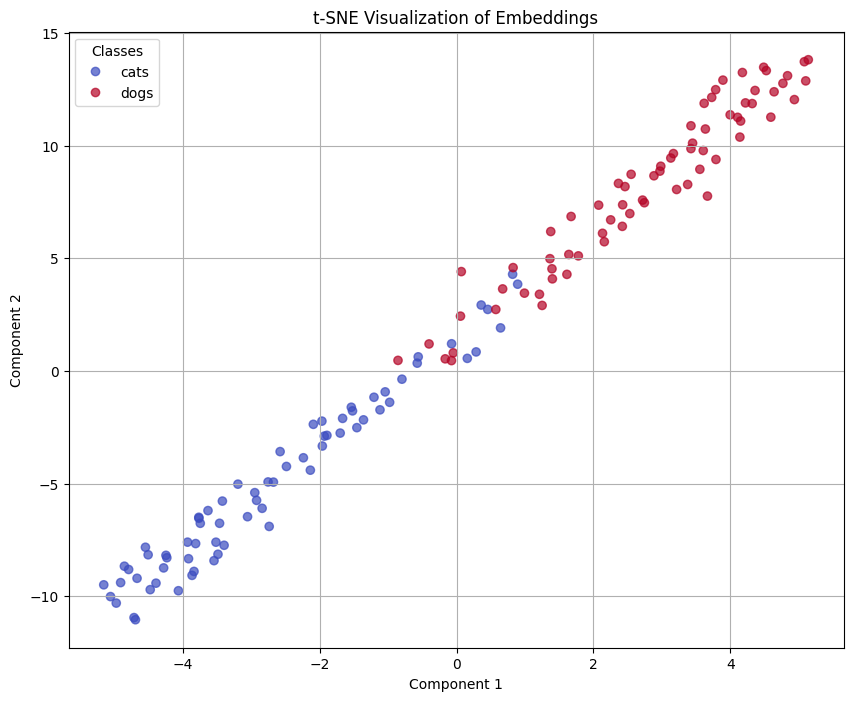

In [13]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
# Step 1: Get embeddings & labels from test data
embeddings_list = []
labels_list = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        embeddings = model.forward_once(imgs)
        embeddings_list.append(embeddings.cpu())
        labels_list.extend(labels.cpu().numpy())

embeddings_tensor = torch.cat(embeddings_list)
labels_np = np.array(labels_list)

# Step 2: Run t-SNE to reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_tensor.numpy())

# Step 3: Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_np, cmap='coolwarm', alpha=0.7)
plt.legend(handles=scatter.legend_elements()[0], labels=train_dataset.classes, title="Classes")
plt.title("t-SNE Visualization of Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork().to(device)
classifier = Classifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(model.parameters()) + list(classifier.parameters()), lr=1e-4)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


In [10]:
num_epochs = 10

model.train()
classifier.train()

for epoch in range(num_epochs):
    total_loss = 0.0
    correct = 0
    total = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        embeddings = model.forward_once(imgs)
        outputs = classifier(embeddings)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total * 100
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}, Accuracy: {acc:.2f}%")


Epoch 1/10, Loss: 0.0587, Accuracy: 100.00%
Epoch 2/10, Loss: 0.0531, Accuracy: 99.82%
Epoch 3/10, Loss: 0.1760, Accuracy: 99.64%
Epoch 4/10, Loss: 0.0837, Accuracy: 99.82%
Epoch 5/10, Loss: 0.2650, Accuracy: 99.46%
Epoch 6/10, Loss: 0.3650, Accuracy: 99.28%
Epoch 7/10, Loss: 0.6553, Accuracy: 98.74%
Epoch 8/10, Loss: 0.2468, Accuracy: 99.46%
Epoch 9/10, Loss: 0.2108, Accuracy: 99.46%
Epoch 10/10, Loss: 0.3551, Accuracy: 99.10%


In [11]:
model.eval()
classifier.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        embeddings = model.forward_once(imgs)
        outputs = classifier(embeddings)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog']))


              precision    recall  f1-score   support

         Cat       0.93      0.93      0.93        70
         Dog       0.93      0.93      0.93        70

    accuracy                           0.93       140
   macro avg       0.93      0.93      0.93       140
weighted avg       0.93      0.93      0.93       140

